# **Importing Basic Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
	# pip install streamlit==1.38.0
  # pip install lightgbm==4.5.0
  # pip install scikit-learn==1.6.0
  # pip install pandas==2.2.3
  # pip install numpy==1.26.4

# **Reading Dataset**

In [ ]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# **Handling Missing Values**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data = data.drop('customerID', axis=1)
data.TotalCharges = pd.to_numeric(data.TotalCharges, errors="coerce")
data['TotalCharges'] = data['TotalCharges'].fillna(0)
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

In [ ]:
def ContractService(data):
    if data.InternetService == 'DSL' and data.Contract == 'Month-to-month':
        return 'Dmonth'
    elif data.InternetService == 'DSL' and data.Contract == 'One year':
        return  'D1year'
    elif data.InternetService == 'DSL' and data.Contract == 'Two year':
        return  'D2years'
    elif data.InternetService == 'Fiber optic' and data.Contract == 'Month-to-month':
        return  'Fmonth'
    elif data.InternetService == 'Fiber optic' and data.Contract == 'One year':
        return  'F1year'
    elif data.InternetService == 'Fiber optic' and data.Contract == 'Two year':
        return  'F2years'
    elif data.InternetService == 'No' and data.Contract == 'Month-to-month':
        return  'Nmonth'
    elif data.InternetService == 'No' and data.Contract == 'One year':
        return  'N1year'
    elif data.InternetService == 'No' and data.Contract == 'Two year':
        return  'N2years'

In [ ]:
data['Ave_Charges'] = data['TotalCharges'] / data['MonthlyCharges']
data['ContractService'] = data.apply(ContractService, axis=1)

# **Getting my Target and Feature alues**

In [ ]:
x = data.drop('Churn', axis=1)
y = data['Churn']

# **Getting the categorical and Numerical features**

In [ ]:
cat_cols = x.select_dtypes(include=['object']).columns
num_cols = x.select_dtypes(exclude=['object']).columns

# **Adding plots**

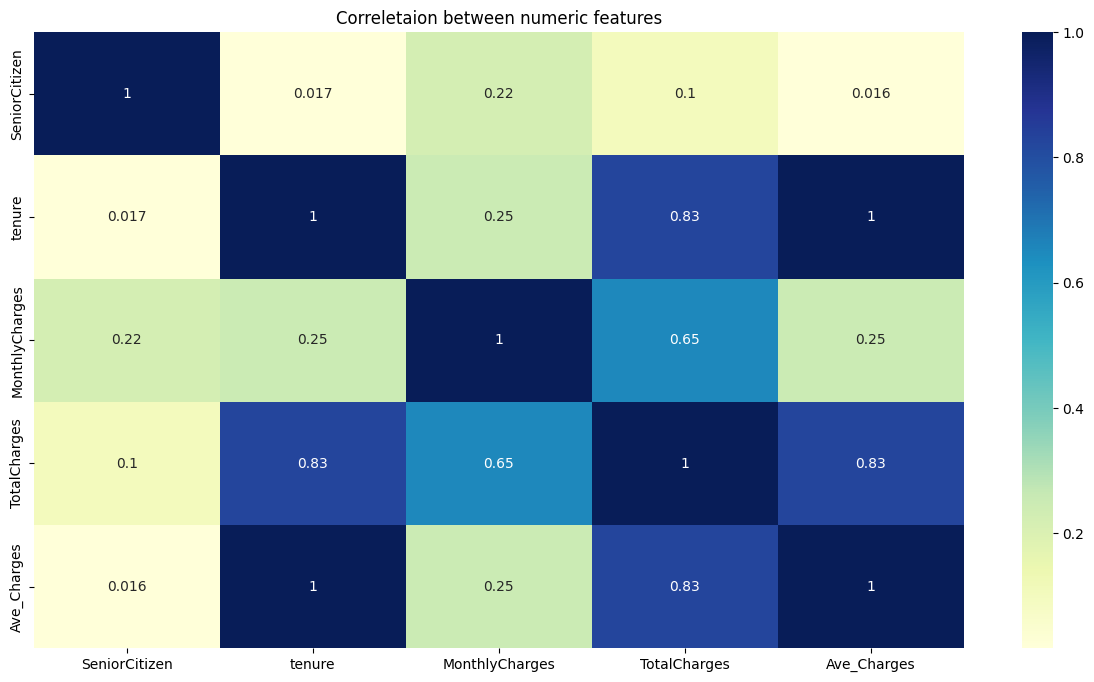

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='YlGnBu')
plt.title("Correletaion between numeric features")
plt.show()

# **Getting Training and Testing set**

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder, StandardScaler

# **Scaling and Ecoding Numerical and Categorical features**

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [('num', MinMaxScaler(), num_cols),
                    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)]
)

# **Hyper Parameter Tunning**

In [ ]:
from lightgbm import  LGBMClassifier
from imblearn.ensemble import BalancedBaggingClassifier
Light = LGBMClassifier(
    objective='binary',
    n_jobs=-1,
    random_state=42
)
BBC = BalancedBaggingClassifier(
    estimator=Light,
    n_jobs=-1,
    random_state=42
)
param = {
    'resample__k_neighbors': [3, 5, 7],
    'model__n_estimators': [10, 20, 30, 50],
    'model__max_samples': [0.6, 0.8, 1.0],
    'model__max_features': [0.7, 0.9, 1.0],
    'model__estimator__num_leaves': [31, 63],
    'model__estimator__max_depth': [-1, 10, 20],
    'model__estimator__learning_rate': [0.05, 0.1],
    'model__estimator__n_estimators': [10, 20, 30, 50],
    'model__estimator__min_child_sample': [20, 50]
}

# **Incuding my pipeline**

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('resample', SMOTE(random_state=1)),
    ('model', BBC)
])

In [ ]:
Model = RandomizedSearchCV(
    pipe,
    param_distributions=param,
    n_iter=20,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=1
)

# **Training my Model**

In [ ]:
Model.fit(x_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               MinMaxScaler(),
                                                                               Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Ave_Charges'],
      dtype='object')),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService',...
                                        'model__estimator__max_depth': [-1, 10,
                                                                        20],
                                        'model__estimator__min_child_sample': [20,
                                                                               50],
                                        'model__estimator__n_estimators': [10,
                                                                           20,
                                                                           30,
                                                                           50],
                                        'model__estimator__num_leaves': [31,
                                                                         63],
                                        'model__max_features': [0.7, 0.9, 1.0],
                                        'model__max_samples': [0.6, 0.8, 1.0],
                                        'model__n_estimators': [10, 20, 30, 50],
                                        'resample__k_neighbors': [3, 5, 7]},
                   random_state=1, scoring='f1', verbose=2)

In [ ]:
print(f"Best params: {Model.best_params_}")
print(f"Best CV score: {Model.best_score_}")

Best params: {'resample__k_neighbors': 3, 'model__n_estimators': 30, 'model__max_samples': 0.6, 'model__max_features': 0.7, 'model__estimator__num_leaves': 31, 'model__estimator__n_estimators': 10, 'model__estimator__min_child_sample': 20, 'model__estimator__max_depth': 20, 'model__estimator__learning_rate': 0.05}
Best CV score: 0.6339854712890972


# **Model Performance Evaluation**

In [ ]:
y_prob = Model.predict_proba(x_test)[:, 1]
y_pred = (y_prob >= 0.45).astype(int)

In [ ]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [ ]:
print(f"Test ROC AUC: {roc_auc_score(y_test, y_prob)}")

Test ROC AUC: 0.8340050117543725


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.68      0.78      1035
           1       0.49      0.82      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.72      0.74      1409



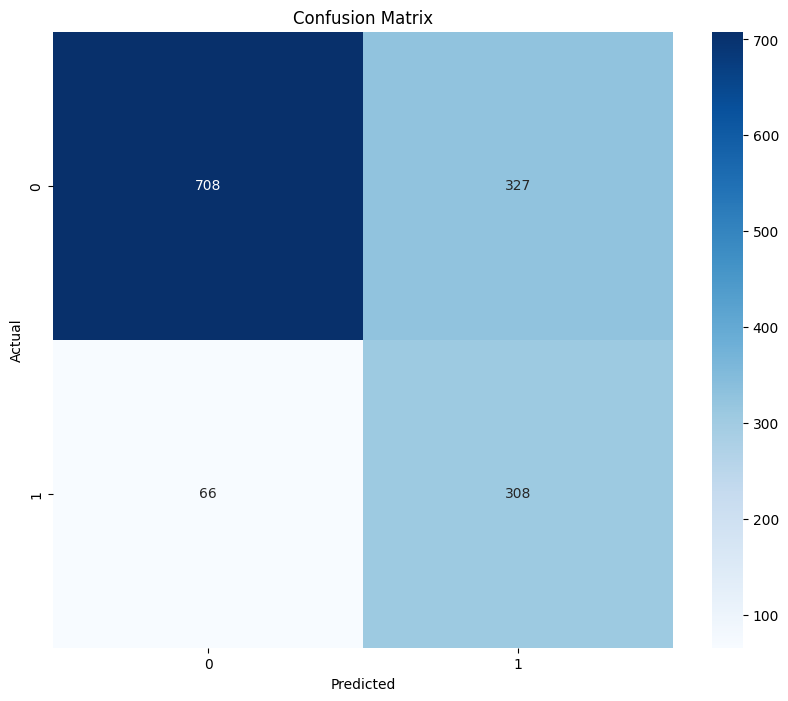

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# xticklabels=['NoChurn', 'Churn'], yticklabels=['NoChurn', 'Churn']
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

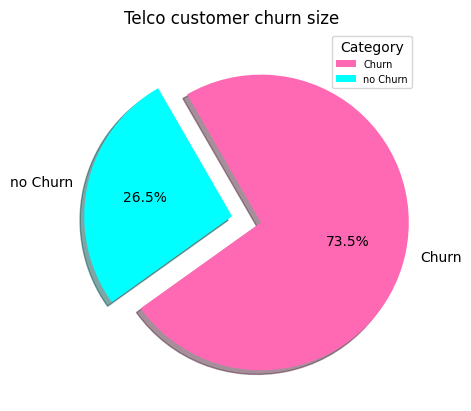

In [ ]:
counts = data['Churn'].value_counts()
explodes = [0.2, 0.0]
appear = ['hotpink', 'cyan', 'brown', 'blue']
names = ['Churn', 'no Churn']
plt.pie(
    counts,
    labels=names,
    autopct='%1.1f%%',
     explode=explodes,
     shadow=True,
     colors=appear,
    startangle=120,
    counterclock=False
)
plt.legend(title='Category', loc='upper right',fontsize=7)
plt.title("Telco customer churn size")
plt.show()

# **Introducing a function for the implemention of the created model**

In [ ]:
import math
def predicted(enter_model_name):
  Cols = x.columns
  numericals = num_cols
  categoricals = cat_cols
  values = {}
  for col in Cols:
    while True:
      value = input(f"Enter value for '{col}': ")
      if col in numericals:
        try:
          value = float(value)
          break
        except ValueError:
          print(f"Invalid input for {value}, Please enter a numeric value")
      elif col in categoricals:
        value = value.replace(' ', '').replace('(', '').replace(')', '').replace('/', '').replace('-', '')
        if value.isalpha():
          break
        else:
          print(f"Invalid input for {value}")
      else:
        break
    values[col] = value
  var_name = col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_').replace('-', '_')
  values[var_name] = value
  datas = pd.DataFrame([values])
  y_pred = Model.predict(datas)
  # y_pred = math.floor(y_pred[0])
  if y_pred == 1:
    print("Customer will likely churn")
  else:
    print("Customer will likely not churn")

# **Creating the sav file for model deployment**

In [ ]:
import pickle
file_name = 'Churn_model.sav'
pickle.dump(Model, open(file_name, 'wb'))

# **THE END**